# Saliency Experiment — Pangu-Weather (24h) via Input Occlusion

Метод: обнуление (zero-out) и замена климатическим средним (climatology-replace) отдельных входных переменных/уровней,
измерение изменения выхода модели. Три части:

1. **Global per-variable occlusion** — вся переменная/уровень целиком, по всему земному шару
2. **Spatial patch occlusion** — локальные пространственные патчи, чтобы увидеть *где* модель наиболее чувствительна
3. **Сравнение с ground truth** — не только Δ(baseline, perturbed), но и что ближе к реальным ERA5 на valid time

Модель: `pangu_weather_24.onnx` (24-часовой прогноз, ONNX, лицензия CC-BY-NC-SA-4.0, некоммерческое использование).

Тяжёлые вычисления (части 1-2) считаются `run_case_occlusion.py` — отдельным скриптом, параллельно на 3 GPU
(по одному кейсу на GPU), результаты сохранены в `results/<case>.pkl`. Этот ноутбук их загружает и визуализирует.


In [1]:
import os
import sys
import glob
import pickle

# onnxruntime-gpu needs libcublasLt/cuDNN at runtime; reuse the CUDA libs already bundled with the
# torch install in this venv instead of installing a separate system CUDA toolkit.
_nvidia_lib_dirs = glob.glob(os.path.join(sys.prefix, 'lib', 'python3.10', 'site-packages', 'nvidia', '*', 'lib'))
os.environ['LD_LIBRARY_PATH'] = ':'.join(_nvidia_lib_dirs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import onnxruntime as ort

plt.rcParams['figure.dpi'] = 110

PRESSURE_LEVELS_HPA = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]
SURFACE_ORDER = ['mean_sea_level_pressure', '10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature']
UPPER_ORDER = ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind']
CASES = ['storm_eunice', 'heatwave_block', 'quiet_baseline']
CASE_DATES = {
    'storm_eunice':   '2022-02-18T12:00',
    'heatwave_block': '2022-07-18T12:00',
    'quiet_baseline': '2021-10-05T12:00',
}


## 1. Загрузка результатов параллельного прогона (`results/<case>.pkl`)


In [2]:
case_results = {}
for case in CASES:
    with open(f'results/{case}.pkl', 'rb') as f:
        case_results[case] = pickle.load(f)
    print(case, '-> keys:', list(case_results[case].keys()))


storm_eunice -> keys: ['global_results', 'spatial_saliency', 'baseline_output', 'std_surface', 'std_upper']


heatwave_block -> keys: ['global_results', 'spatial_saliency', 'baseline_output', 'std_surface', 'std_upper']
quiet_baseline -> keys: ['global_results', 'spatial_saliency', 'baseline_output', 'std_surface', 'std_upper']


## 2. Визуализация: значимость переменных (global occlusion)


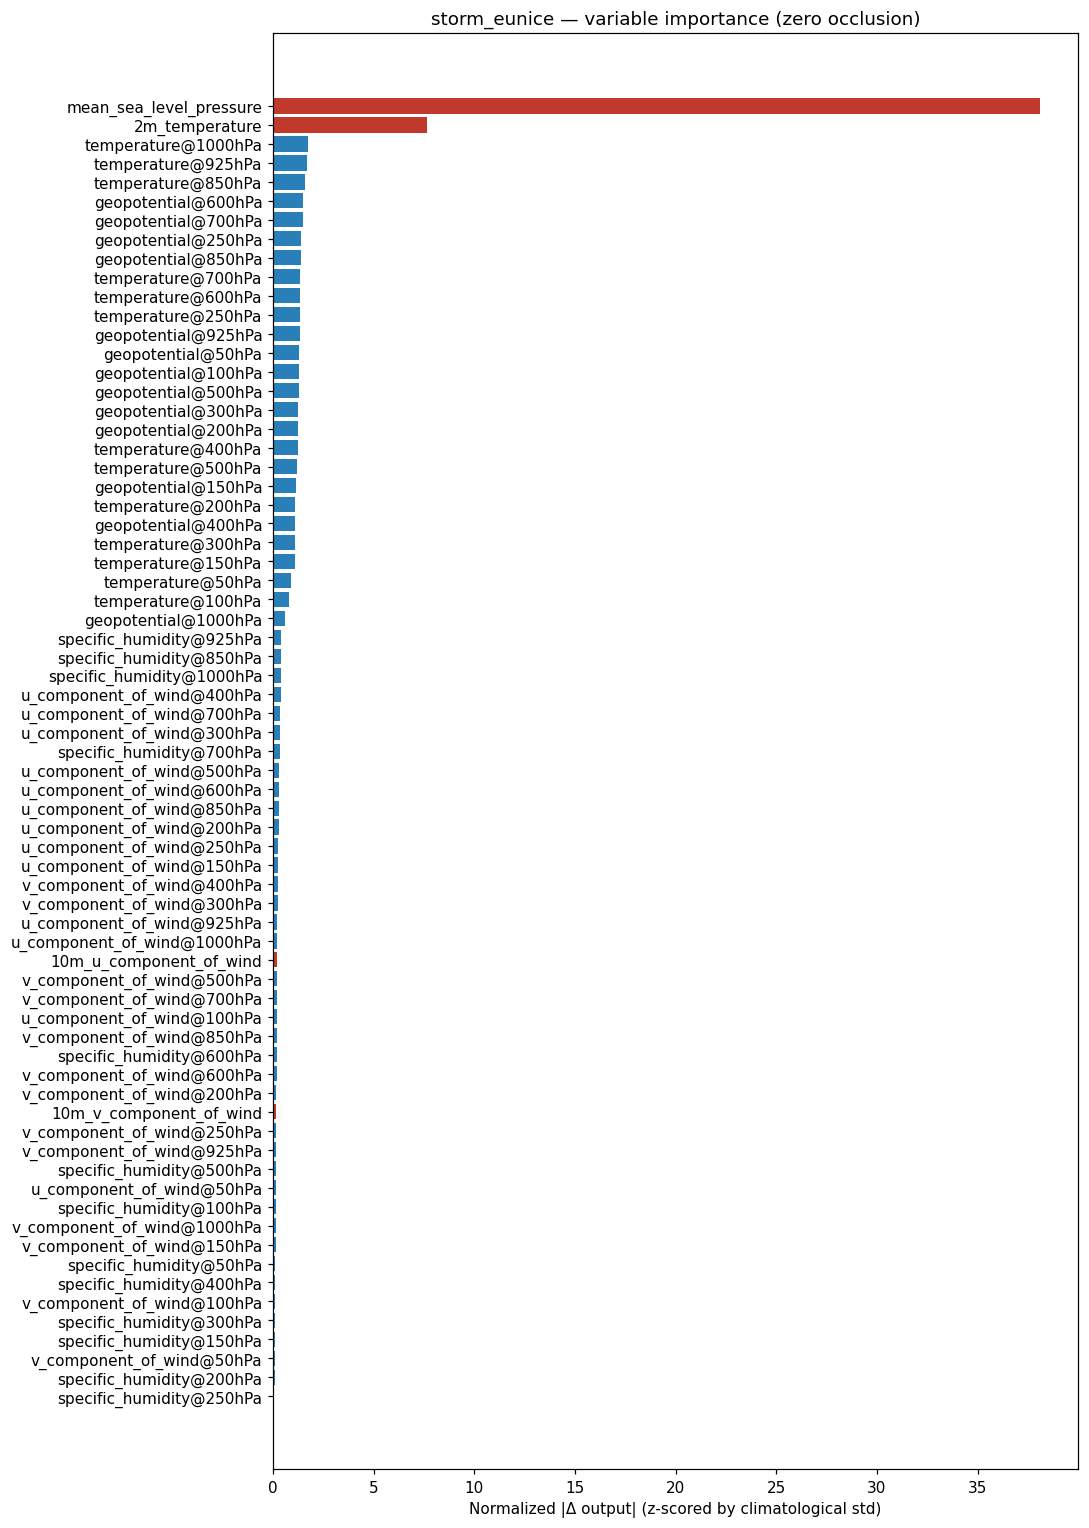

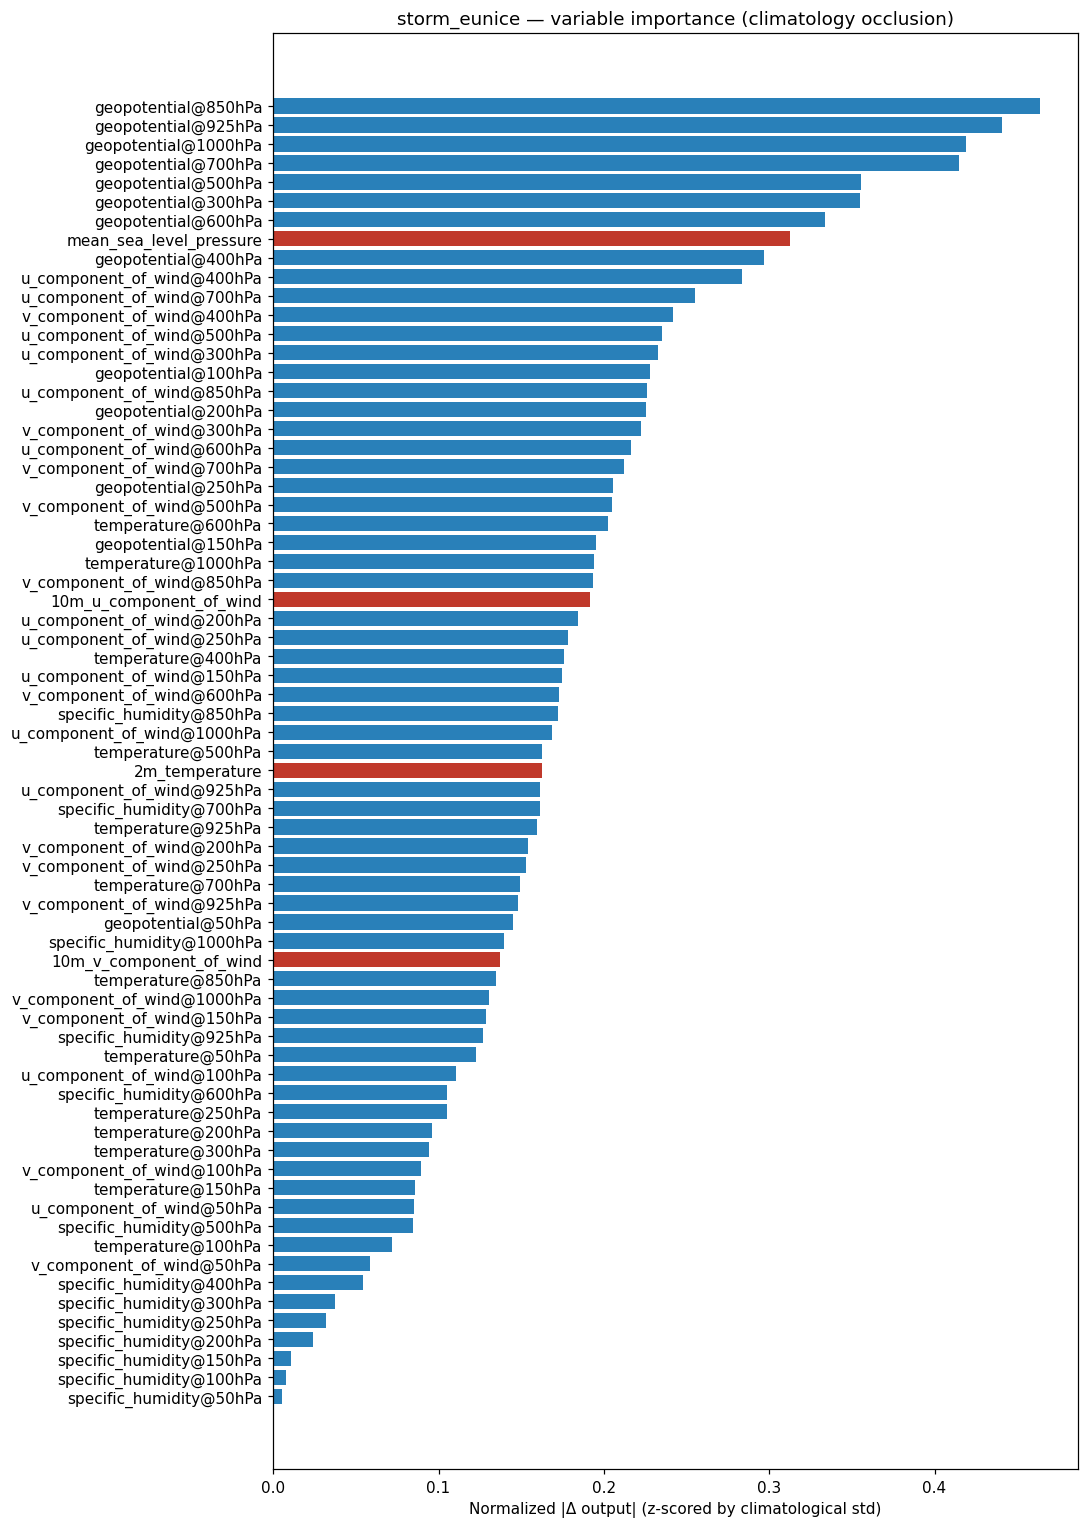

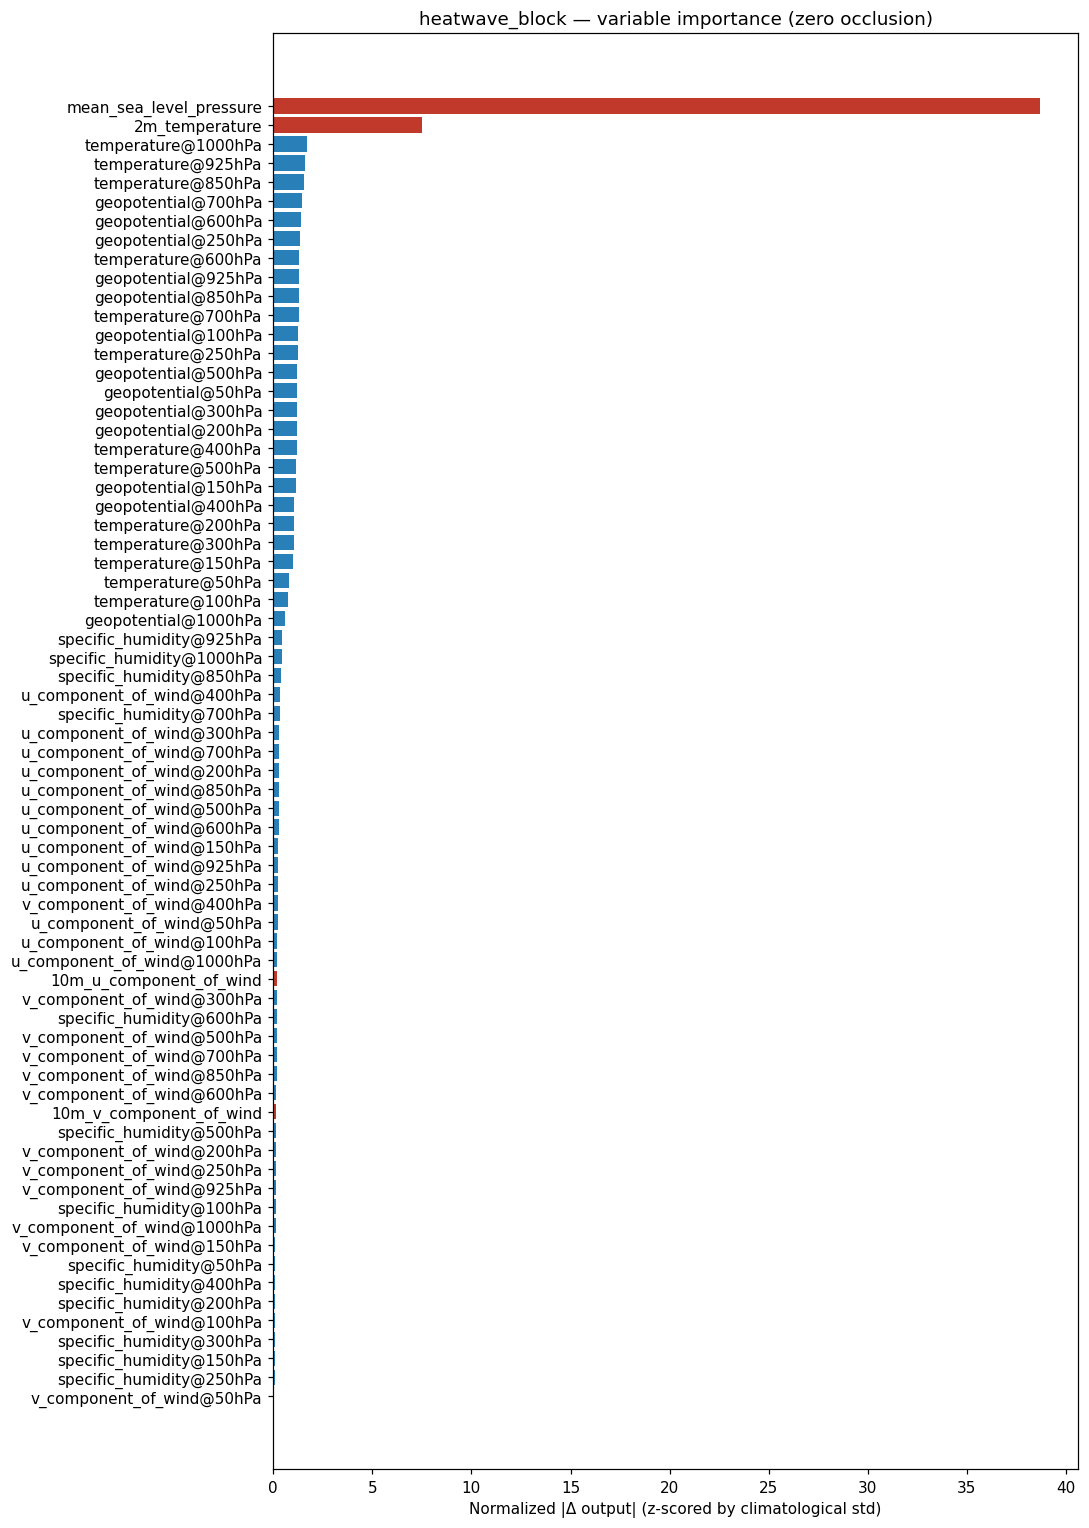

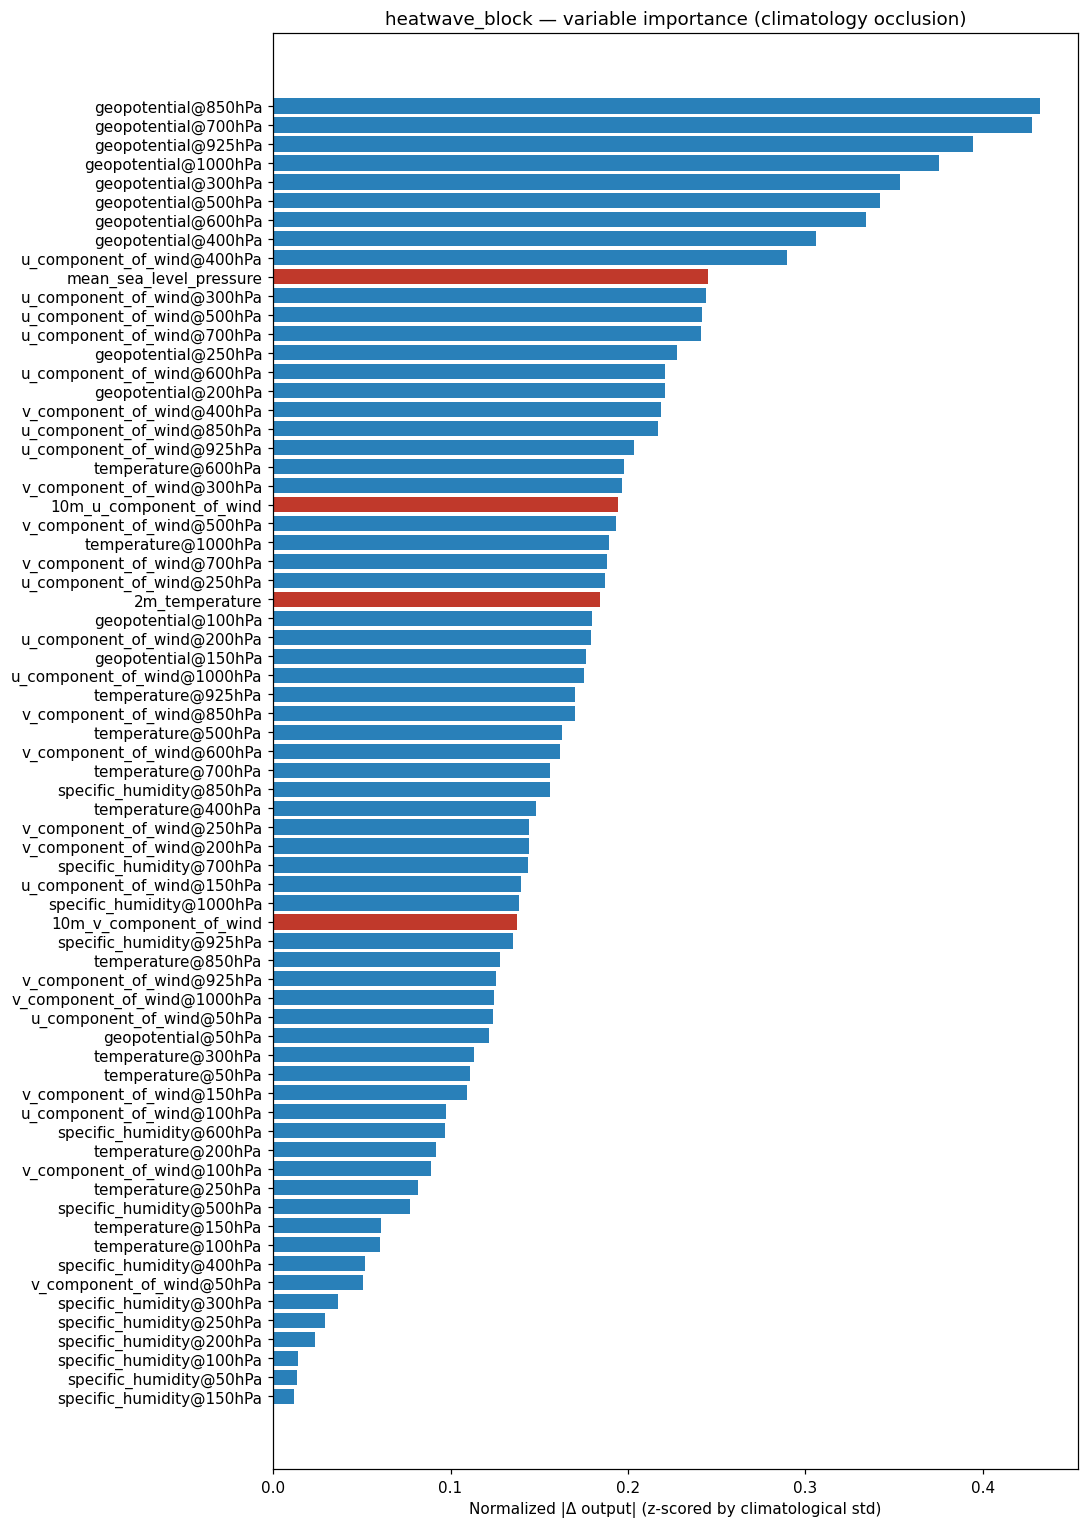

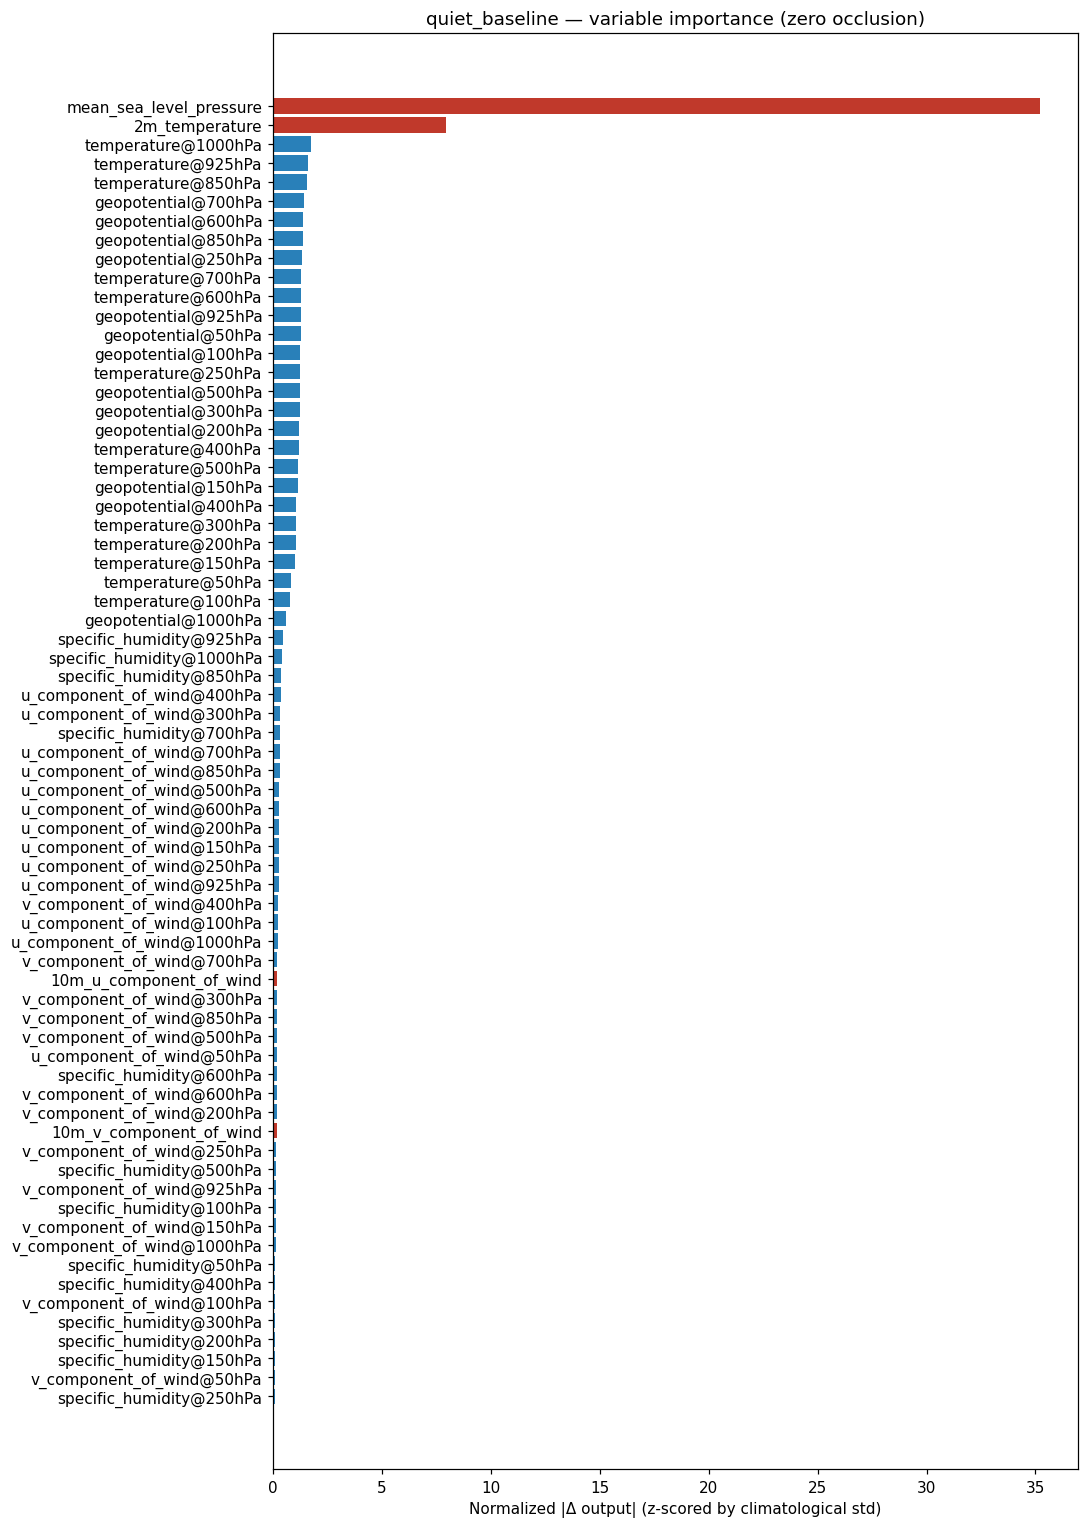

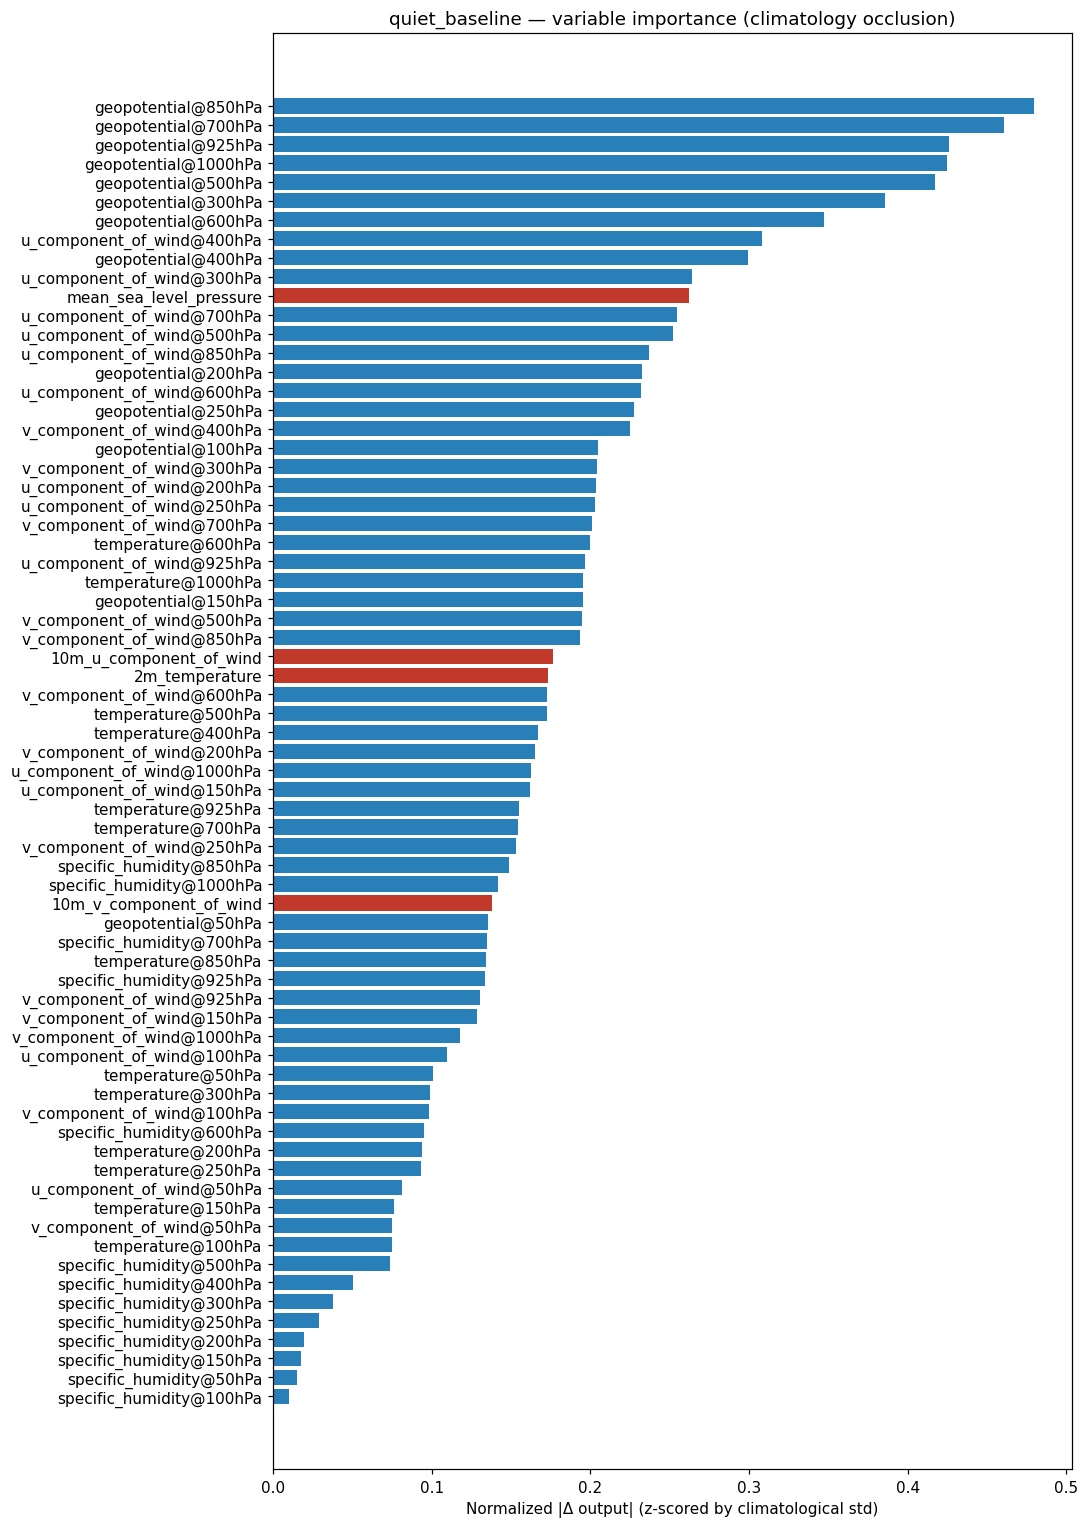

In [3]:
def plot_variable_importance(case, mode):
    results = case_results[case]['global_results'][mode]
    labels = [f"{r['channel']}" if r['level'] is None else f"{r['channel']}@{r['level']}hPa" for r in results]
    scores = [r['score'] for r in results]

    order = np.argsort(scores)[::-1]
    labels = [labels[i] for i in order]
    scores = [scores[i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 14))
    colors = ['#c0392b' if lbl.split('@')[0] in SURFACE_ORDER else '#2980b9' for lbl in labels]
    ax.barh(labels, scores, color=colors)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized |Δ output| (z-scored by climatological std)')
    ax.set_title(f'{case} — variable importance ({mode} occlusion)')
    plt.tight_layout()
    os.makedirs('figures/02_saliency_experiment', exist_ok=True)
    plt.savefig(f'figures/02_saliency_experiment/{case}_{mode}_importance.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    for mode in ['zero', 'climatology']:
        plot_variable_importance(case, mode)


## 3. Spatial patch occlusion — MSLP и Z@500hPa

**Важно**: не берём автоматически топ-1 канал по score — на первом прогоне это оказался Z@850hPa, и spatial map
получилась испорчена орографией (850hPa часто ниже поверхности над горами — Чукотка/Камчатка, южные острова
~55°S — ERA5 экстраполирует geopotential там, значения нестабильны, occlusion даёт большой |Δoutput| просто
из-за шума в данных). Проверка: `quiet_baseline` показал ровно те же пятна в тех же местах, что и `storm_eunice`
— эффект не зависит от погоды, значит артефакт метода, не сигнал. Поэтому используются фиксированные,
орографически безопасные каналы: **MSLP** (приведено к уровню моря) и **Z@500hPa** (свободная атмосфера).


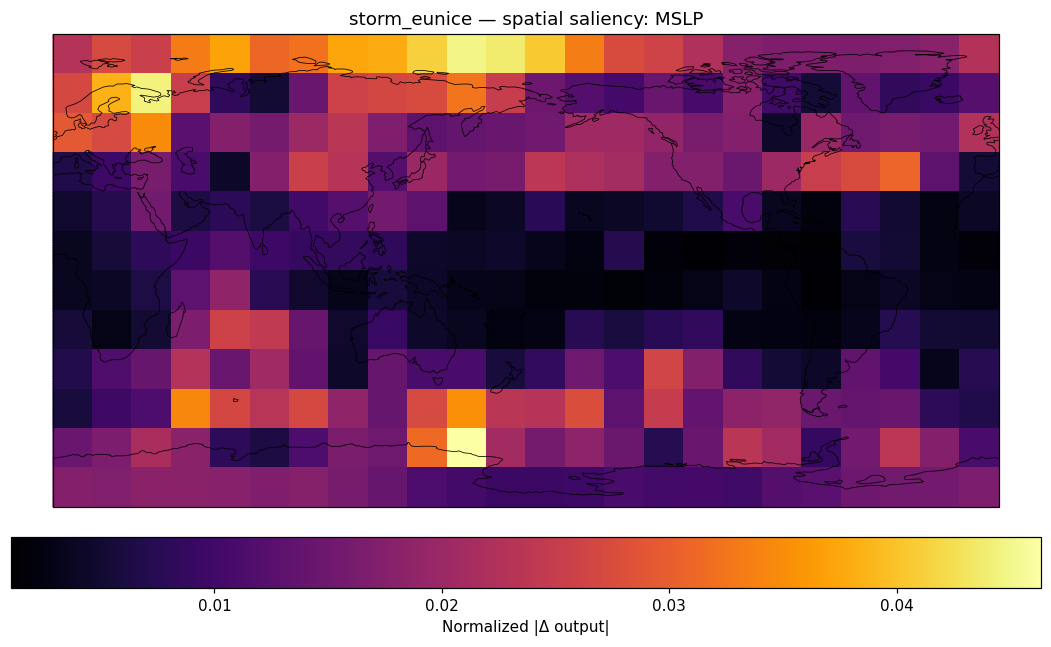

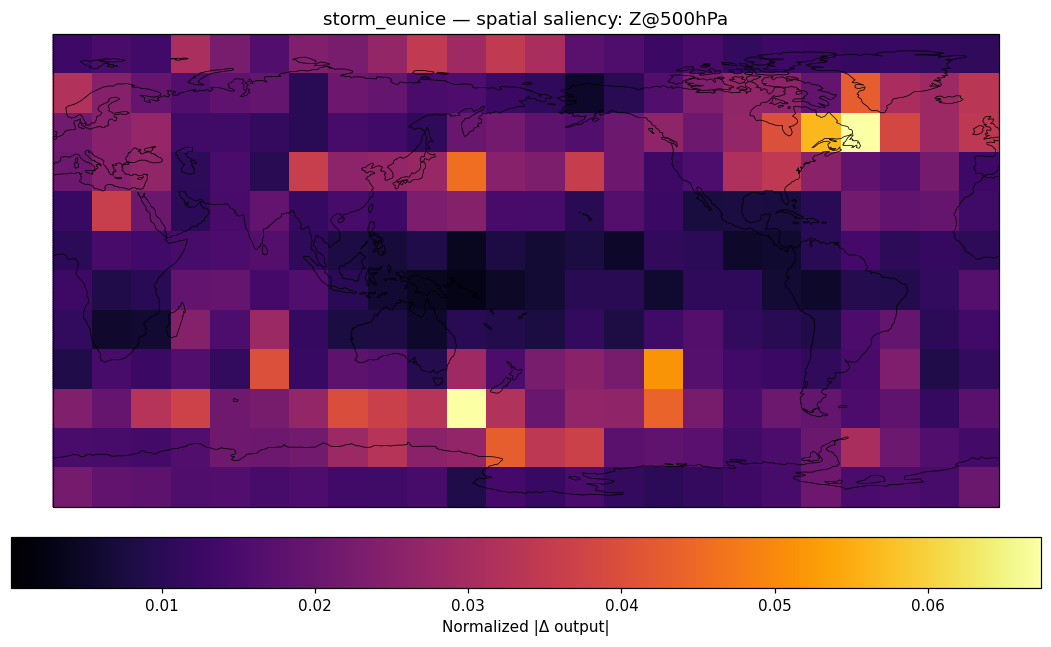

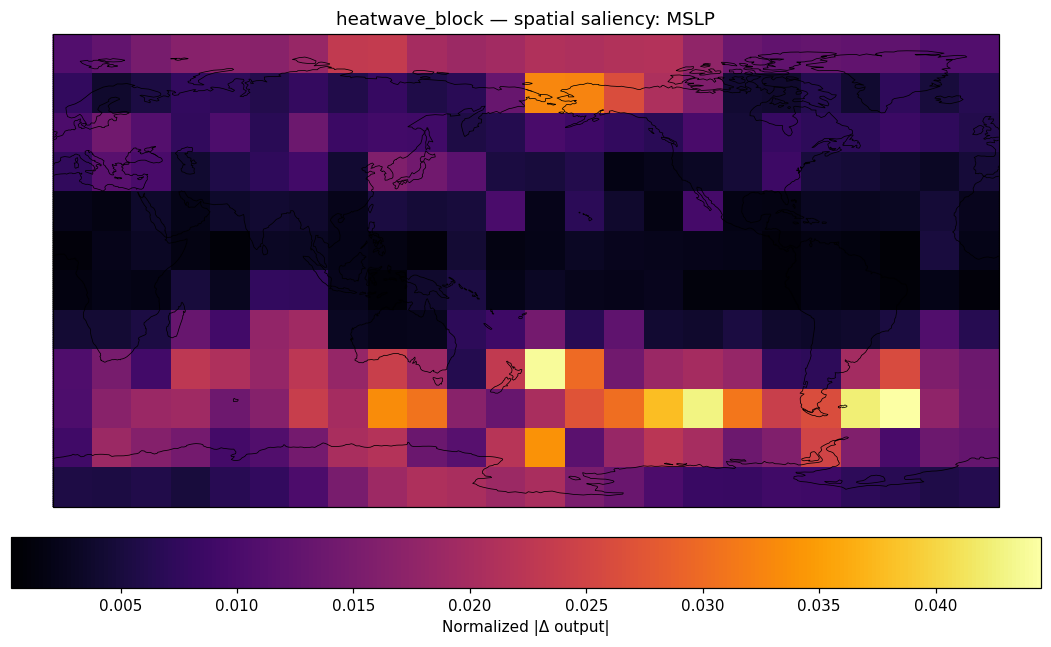

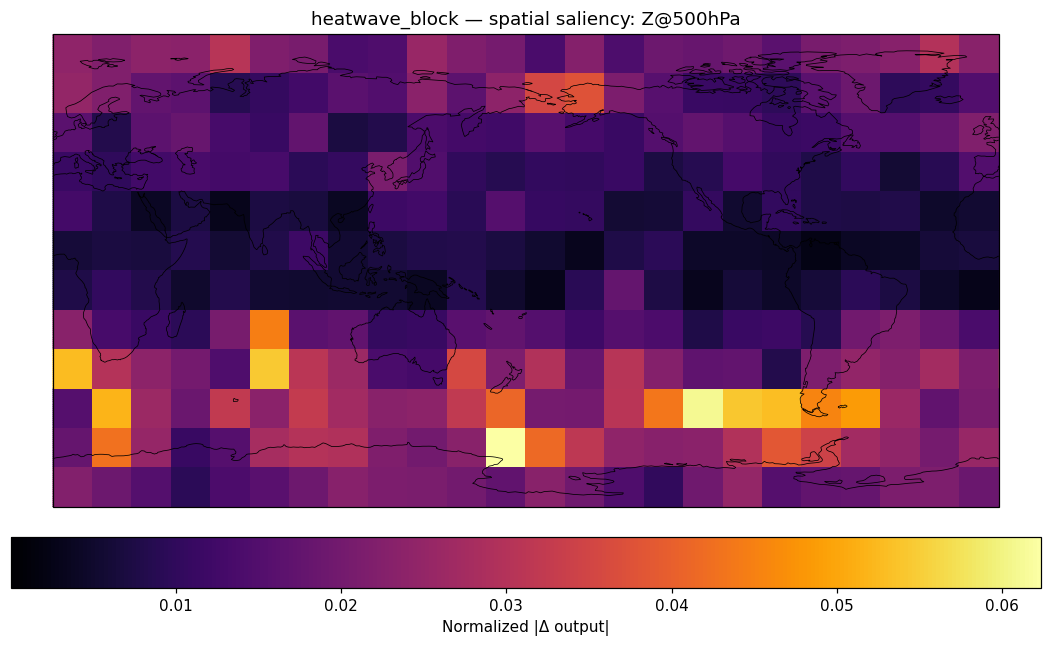

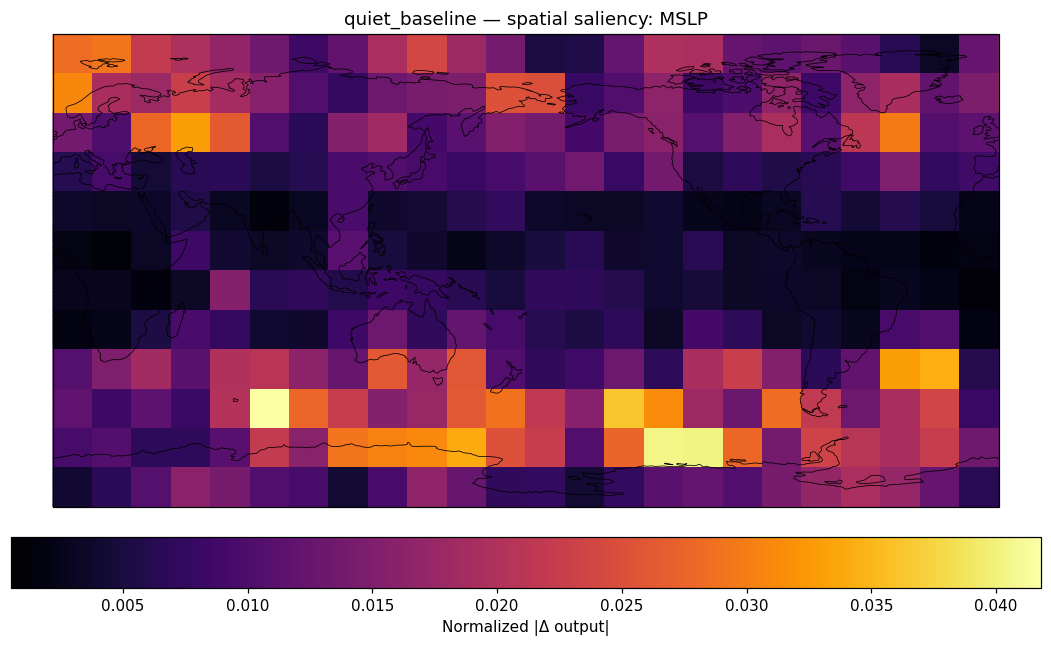

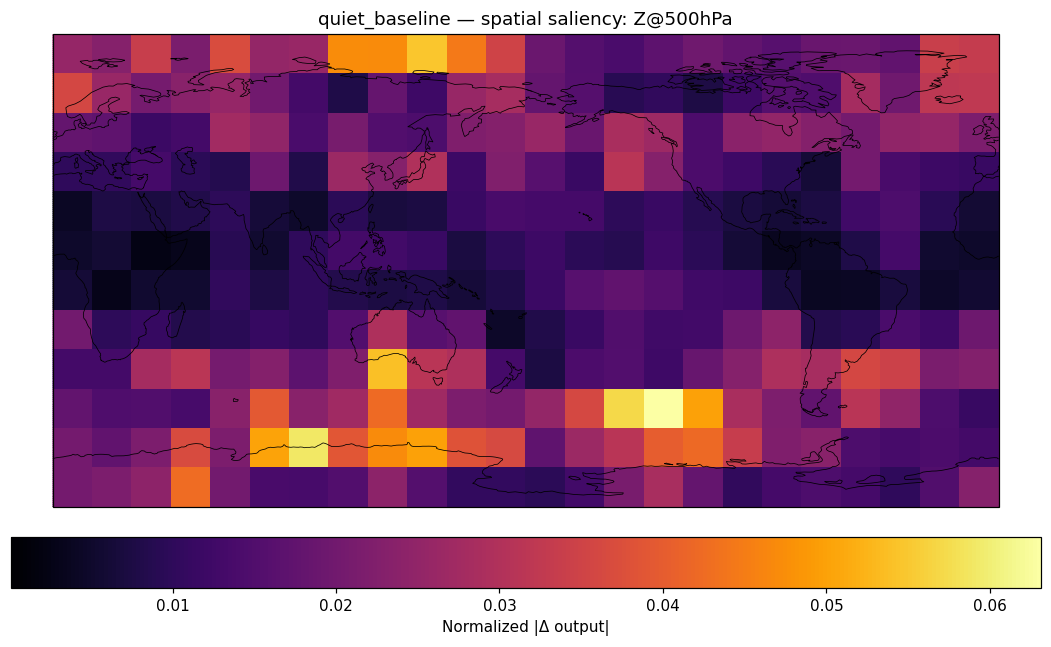

In [4]:
def plot_spatial_saliency(case, label):
    sal = case_results[case]['spatial_saliency'][label]

    lats = np.linspace(90, -90, 721)
    lons = np.linspace(0, 359.75, 1440)

    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    im = ax.pcolormesh(lons, lats, sal, transform=ccrs.PlateCarree(), cmap='inferno')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, label='Normalized |Δ output|')
    ax.set_title(f'{case} — spatial saliency: {label}')
    plt.tight_layout()
    plt.savefig(f'figures/02_saliency_experiment/{case}_{label.replace("@", "_")}_spatial_saliency.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    for label in ['MSLP', 'Z@500hPa']:
        plot_spatial_saliency(case, label)


## 4. Физическая валидация (качественная)

- **Storm Eunice**: ожидаем высокую значимость MSLP/Z и апстрим-регион (Северная Атлантика) — динамика взрывного циклогенеза определяется положением струйного течения и верхнеуровневой завихренностью выше по потоку.
- **Волна тепла/блокинг**: ожидаем значимость геопотенциала на средних уровнях (Z500) над самим регионом блокинга — устойчивый антициклон определяется полем Z500, а не поверхностными переменными.
- **Спокойный день**: ожидаем более равномерную/низкоамплитудную картину значимости без выраженного пространственного пика — резкий пик здесь означал бы артефакт метода, а не реальную физику.

*(Сверить визуально с картами из `01_era5_visualization.ipynb`.)*


## 5. Сравнение с ground truth

До сих пор мы сравнивали **baseline forecast** (прогноз на неизменном входе) с **perturbed forecast** (прогноз
после occlusion) — то есть "насколько сильно изменился прогноз модели". Это не говорит, стал ли прогноз *лучше*
или *хуже* относительно реальности.

Здесь: берём топ-3 канала (по climatology-occlusion score) для каждого кейса, реально повторяем occlusion, и
сравниваем **обе версии прогноза** (baseline и perturbed) с **настоящими ERA5-данными на valid time**
(`case_time + 24h`) — какой из двух ближе к правде.


In [5]:
MODEL_PATH = 'model_weights/pangu_weather_24.onnx'
session = ort.InferenceSession(MODEL_PATH, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
print('Providers in use:', session.get_providers())

input_names = [i.name for i in session.get_inputs()]
output_names = [o.name for o in session.get_outputs()]


def run_model(input_surface, input_upper):
    name_map = {}
    for name in input_names:
        name_map[name] = input_surface if 'surface' in name.lower() else input_upper
    raw = session.run(None, name_map)
    by_name = dict(zip(output_names, raw))
    out_surf = next(v for k, v in by_name.items() if 'surface' in k.lower())
    out_upp = next(v for k, v in by_name.items() if 'surface' not in k.lower())
    return out_surf, out_upp


def to_pangu_lon(ds):
    return ds.assign_coords(longitude=(ds.longitude % 360)).sortby('longitude')


Providers in use: ['CUDAExecutionProvider', 'CPUExecutionProvider']


In [6]:
ARCO_URL = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
ds_arco = xr.open_zarr(ARCO_URL, storage_options=dict(token='anon'), chunks=None)
ds_arco = ds_arco.assign_coords(longitude=(ds_arco.longitude % 360)).sortby('longitude')

CLIMATOLOGY_YEARS_BACK = 8


def compute_climatology(case_key):
    base_time = np.datetime64(CASE_DATES[case_key])
    sample_times = [base_time - np.timedelta64(365 * i, 'D') for i in range(1, CLIMATOLOGY_YEARS_BACK + 1)]
    surface_samples = ds_arco[SURFACE_ORDER].sel(time=sample_times, method='nearest').load()
    upper_samples = ds_arco[UPPER_ORDER].sel(time=sample_times, method='nearest').sel(level=PRESSURE_LEVELS_HPA).load()
    clim_surface = np.stack([surface_samples[v].mean(dim='time').values for v in SURFACE_ORDER], axis=0).astype(np.float32)
    clim_upper = np.stack([upper_samples[v].mean(dim='time').values for v in UPPER_ORDER], axis=0).astype(np.float32)
    return clim_surface, clim_upper


def fetch_ground_truth(case_key):
    """Real ERA5 state at valid time = case_time + 24h (the time the model is forecasting for)."""
    valid_time = np.datetime64(CASE_DATES[case_key]) + np.timedelta64(24, 'h')
    snapshot = ds_arco.sel(time=valid_time, method='nearest')
    truth_surface = np.stack([snapshot[v].values for v in SURFACE_ORDER], axis=0).astype(np.float32)
    truth_upper = np.stack(
        [snapshot[v].sel(level=PRESSURE_LEVELS_HPA).values for v in UPPER_ORDER], axis=0).astype(np.float32)
    return truth_surface, truth_upper


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


In [7]:
ground_truth_comparison = {}

for case in CASES:
    print(f'--- {case} ---')
    surface_ds = to_pangu_lon(xr.open_dataset(f'data/{case}_surface.nc'))
    upper_ds = to_pangu_lon(xr.open_dataset(f'data/{case}_upper_air.nc')).sel(level=PRESSURE_LEVELS_HPA)
    input_surface = np.stack([surface_ds[v].values for v in SURFACE_ORDER], axis=0).astype(np.float32)
    input_upper = np.stack([upper_ds[v].values for v in UPPER_ORDER], axis=0).astype(np.float32)

    clim_surface, clim_upper = compute_climatology(case)
    truth_surface, truth_upper = fetch_ground_truth(case)

    baseline_surf, baseline_upp = run_model(input_surface, input_upper)
    baseline_rmse = {v: rmse(baseline_surf[i], truth_surface[i]) for i, v in enumerate(SURFACE_ORDER)}

    climatology_results = case_results[case]['global_results']['climatology']
    top3 = sorted(climatology_results, key=lambda r: r['score'], reverse=True)[:3]

    case_comparison = {'baseline_rmse': baseline_rmse, 'perturbed': []}
    for top in top3:
        surf = input_surface.copy()
        upp = input_upper.copy()
        if top['level'] is None:
            var_idx = SURFACE_ORDER.index(top['channel'])
            surf[var_idx] = clim_surface[var_idx]
        else:
            var_idx = UPPER_ORDER.index(top['channel'])
            level_idx = PRESSURE_LEVELS_HPA.index(top['level'])
            upp[var_idx, level_idx] = clim_upper[var_idx, level_idx]

        pert_surf, pert_upp = run_model(surf, upp)
        pert_rmse = {v: rmse(pert_surf[i], truth_surface[i]) for i, v in enumerate(SURFACE_ORDER)}

        label = top['channel'] if top['level'] is None else f"{top['channel']}@{top['level']}hPa"
        case_comparison['perturbed'].append({'label': label, 'rmse': pert_rmse})
        print(f'  {label}: baseline RMSE(T2M)={baseline_rmse["2m_temperature"]:.3f} '
              f'-> perturbed RMSE(T2M)={pert_rmse["2m_temperature"]:.3f}')

    ground_truth_comparison[case] = case_comparison

print('Done.')


--- storm_eunice ---


  geopotential@850hPa: baseline RMSE(T2M)=1.188 -> perturbed RMSE(T2M)=1.478


  geopotential@925hPa: baseline RMSE(T2M)=1.188 -> perturbed RMSE(T2M)=2.782


  geopotential@1000hPa: baseline RMSE(T2M)=1.188 -> perturbed RMSE(T2M)=1.952
--- heatwave_block ---


  geopotential@850hPa: baseline RMSE(T2M)=1.256 -> perturbed RMSE(T2M)=1.674


  geopotential@700hPa: baseline RMSE(T2M)=1.256 -> perturbed RMSE(T2M)=1.568


  geopotential@925hPa: baseline RMSE(T2M)=1.256 -> perturbed RMSE(T2M)=2.146
--- quiet_baseline ---


  geopotential@850hPa: baseline RMSE(T2M)=1.283 -> perturbed RMSE(T2M)=1.597


  geopotential@700hPa: baseline RMSE(T2M)=1.283 -> perturbed RMSE(T2M)=1.610


  geopotential@925hPa: baseline RMSE(T2M)=1.283 -> perturbed RMSE(T2M)=2.365
Done.


## 6. Визуализация: baseline vs perturbed RMSE относительно ground truth

Если удаление канала (замена климатологией) **увеличивает** RMSE относительно правды — канал был полезен для
точности прогноза (не только "менял выход", а действительно помогал предсказывать реальность). Если RMSE
**уменьшается** — occlusion неожиданно улучшил прогноз для этой конкретной переменной (интересный краевой случай,
стоит перепроверить отдельно).


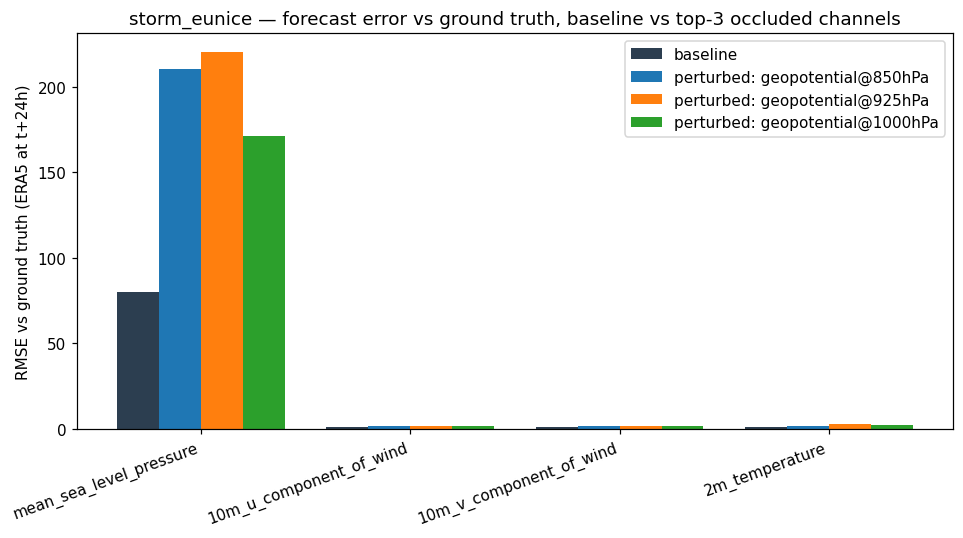

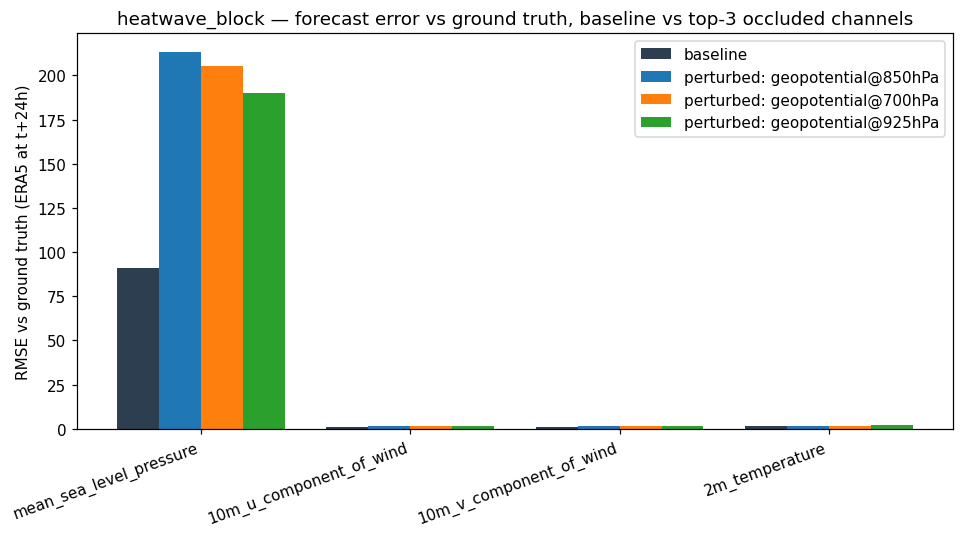

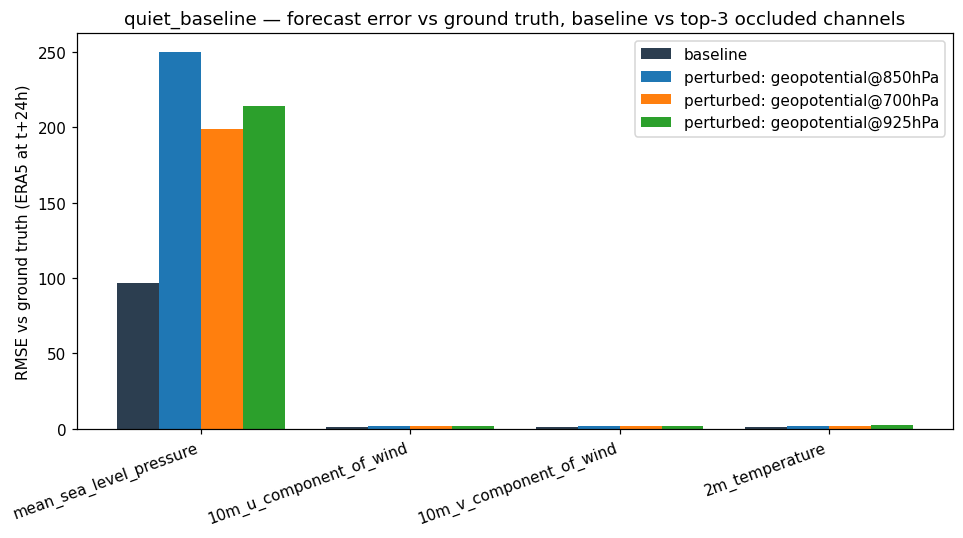

In [8]:
def plot_ground_truth_comparison(case):
    comparison = ground_truth_comparison[case]
    surf_vars = SURFACE_ORDER
    baseline_vals = [comparison['baseline_rmse'][v] for v in surf_vars]

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(surf_vars))
    width = 0.8 / (len(comparison['perturbed']) + 1)

    ax.bar(x - width * (len(comparison['perturbed'])) / 2, baseline_vals, width, label='baseline', color='#2c3e50')
    for i, pert in enumerate(comparison['perturbed']):
        vals = [pert['rmse'][v] for v in surf_vars]
        ax.bar(x - width * (len(comparison['perturbed'])) / 2 + width * (i + 1), vals, width,
               label=f"perturbed: {pert['label']}")

    ax.set_xticks(x)
    ax.set_xticklabels(surf_vars, rotation=20, ha='right')
    ax.set_ylabel('RMSE vs ground truth (ERA5 at t+24h)')
    ax.set_title(f'{case} — forecast error vs ground truth, baseline vs top-3 occluded channels')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'figures/02_saliency_experiment/{case}_ground_truth_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    plot_ground_truth_comparison(case)
